# 08 — Elasticity curves (F2 → F1 feedback)

Fit log-log demand curves `log(qty) = α + β·log(price)` per (SKU × channel). The slope β is the elasticity that F1 uses to size per-SKU safety stock: flat curves → thin buffer, steep curves → fat buffer.

Pipeline:

1. Load `sales_tagged_channel.parquet`, drop stockout weeks and non-positive price/qty.
2. Per (SKU × channel) fit log-log regression. Gate low-data cells (need ≥ 20 obs AND log-price IQR ≥ 0.1 so there's actually some price variation to fit against).
3. Render 4 showcase SKUs × 3 channels = 12 colored scatter panels with fitted curves (blue=clean, orange=promo, red=markdown, grey=stockout).
4. Save `elasticity.parquet` per (SKU × channel).

**Upstream:** sales_tagged_channel.parquet

**Output:** elasticity.parquet, figures in pipeline/artifacts/figures/

**Promotes to:** `src/elasticity.py` once verified.

## 1. Imports

In [1]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'pipeline' else Path.cwd()
DATA = ROOT / 'data'
ART = ROOT / 'pipeline' / 'artifacts'
FIG_DIR = ART / 'figures'
ART.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Thresholds for "we can actually fit a curve here"
MIN_OBS          = 20    # minimum rows per (SKU, channel)
MIN_LOG_PRICE_IQR = 0.1  # log(price) IQR — prevents fitting when price barely varies

# Showcase SKUs for the scatter figure
SHOWCASE = ['T-32206', 'F-04111', 'T-22010', 'T-31510']

## 2. Load upstream

In [2]:
sales = pd.read_parquet(ART / 'sales_tagged_channel.parquet')
print(f'sales       : {sales.shape}')

# Exclude rows F2 must not fit on:
# - is_stockout_week True: supply was capped, observed qty lies about demand
# - non-positive price or qty: can't take log
# - null channel: can't segment
# is_stockout_week is a nullable boolean (NA when inventory coverage is missing);
# fillna(False) keeps those rows — only confirmed stockouts get excluded.
stockout_mask = sales['is_stockout_week'].fillna(False).astype(bool)

elig = sales.loc[
    (~stockout_mask)
    & sales['SALESCHANNEL'].notna()
    & (sales['Unit_Price_adj'] > 0)
    & (sales['QTY_BASE'] > 0)
].copy()

print(f'eligible rows: {len(elig):,} / {len(sales):,}  ({len(elig)/len(sales)*100:.1f}%)')
print(f'  excluded by stockout : {stockout_mask.sum()}')
print(f'  excluded by null chan: {sales["SALESCHANNEL"].isna().sum()}')
print(f'  excluded by price<=0 : {(sales["Unit_Price_adj"] <= 0).sum()}')
print(f'  excluded by qty<=0   : {(sales["QTY_BASE"] <= 0).sum()}')
print()
print(f'tag mix of eligible rows (for scatter coloring):')
print(f'  clean    : {(elig["is_clean_demand"]).sum():,}')
print(f'  promo    : {(elig["is_promo"]).sum():,}')
print(f'  markdown : {(elig["is_markdown"]).sum():,}')

sales       : (236818, 44)
eligible rows: 229,022 / 236,818  (96.7%)
  excluded by stockout : 98
  excluded by null chan: 4
  excluded by price<=0 : 7696
  excluded by qty<=0   : 120

tag mix of eligible rows (for scatter coloring):
  clean    : 170,093
  promo    : 29,391
  markdown : 31,486


## 3. Do the work

In [3]:
# Per (SKU × channel) log-log fit: log(qty) = alpha + beta * log(price).
# beta is the elasticity slope — interpreted as "% change in qty per 1%
# change in price." Expected to be negative for normal goods.

from src.elasticity import fit_elasticity

elasticity = fit_elasticity(
    sales,
    min_obs=MIN_OBS,
    min_log_price_iqr=MIN_LOG_PRICE_IQR,
)

print(f'elasticity shape   : {elasticity.shape}')
print(f'fitted cells       : {(~elasticity["is_low_data"]).sum()}')
print(f'low-data cells     : {elasticity["is_low_data"].sum()}')
print()
print('slope distribution (fitted cells only):')
fit = elasticity[~elasticity['is_low_data']]
print(fit['slope'].describe().to_string())
print()
print(f'  negative slopes : {(fit["slope"] < 0).sum()} / {len(fit)}  (expected majority)')
print(f'  |slope| > 2     : {(fit["slope"].abs() > 2).sum()}  (very elastic)')
print(f'  |slope| < 0.5   : {(fit["slope"].abs() < 0.5).sum()}  (near-inelastic)')
print()
print('R² distribution:')
print(fit['r_squared'].describe().to_string())

elasticity shape   : (207, 11)
fitted cells       : 135
low-data cells     : 72

slope distribution (fitted cells only):
count    135.000000
mean      -3.157650
std        2.173276
min      -10.898293
25%       -4.266891
50%       -3.025384
75%       -1.861717
max        1.082227

  negative slopes : 124 / 135  (expected majority)
  |slope| > 2     : 97  (very elastic)
  |slope| < 0.5   : 7  (near-inelastic)

R² distribution:
count    135.000000
mean       0.373364
std        0.265625
min        0.000071
25%        0.092893
50%        0.380844
75%        0.597050
max        0.909749


## 4. Validate

=== Showcase SKU elasticity slopes ===
ITEMNMBR SALESCHANNEL  n_obs     slope  r_squared  median_price  predicted_qty_at_median  is_low_data
 F-04111           AM   8007       NaN        NaN      1.333750                      NaN         True
 F-04111           HF   1330 -0.135479   0.000250      1.087794               496.298535        False
 F-04111           MM   5078 -4.255459   0.400578      1.477468               177.767022        False
 T-22010           AM   3029 -8.431773   0.660355      4.406667                25.203343        False
 T-22010           HF   1102 -2.743687   0.205947      3.540556               185.309446        False
 T-22010           MM  12822 -4.804376   0.380582      4.195741               202.081454        False
 T-31510           AM    403 -6.713058   0.493912      5.241250                21.341050        False
 T-31510           HF   1575 -1.724516   0.051009      4.073519               271.694153        False
 T-31510           MM  17833 -5.991353   0.

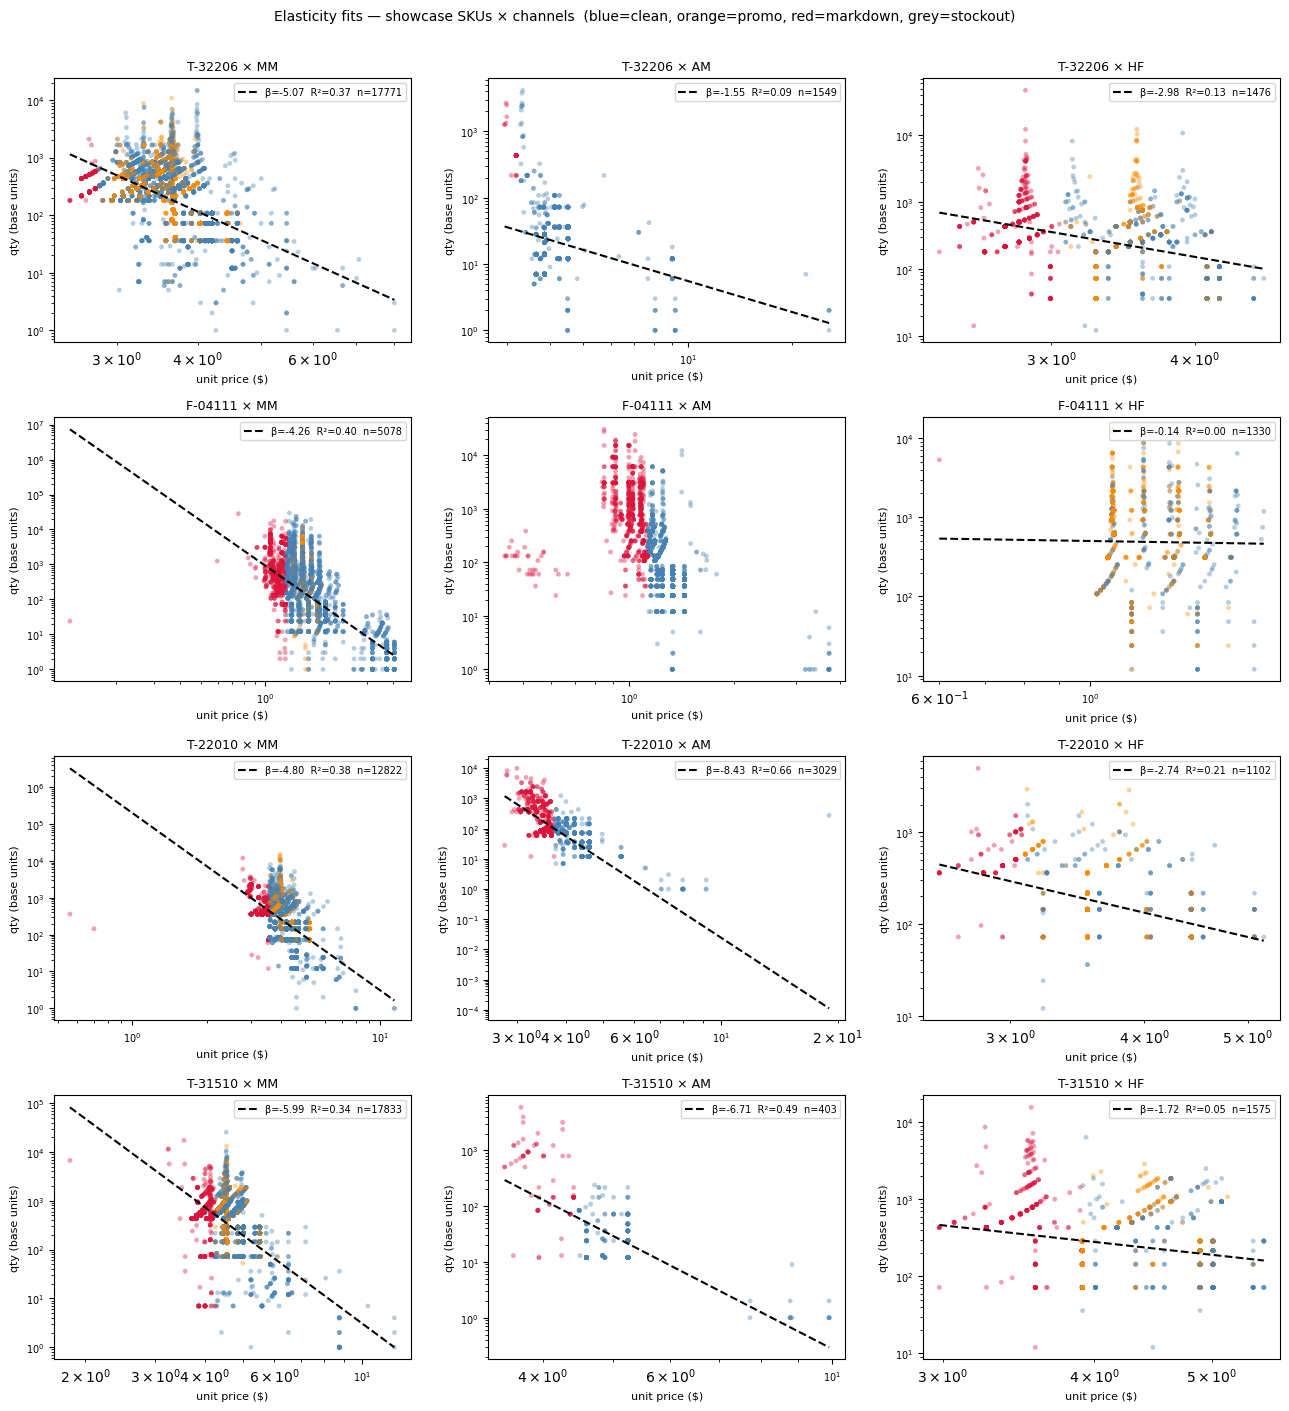


figure saved: /home/johnpork/codeing/pop_prompt2/pipeline/artifacts/figures/elasticity_showcase.png


In [4]:
# ---- Check 1: showcase SKUs — every (SKU, channel) slope ------------------
print('=== Showcase SKU elasticity slopes ===')
show = elasticity[elasticity['ITEMNMBR'].isin(SHOWCASE)].sort_values(
    ['ITEMNMBR', 'SALESCHANNEL'])
cols = ['ITEMNMBR', 'SALESCHANNEL', 'n_obs', 'slope', 'r_squared',
        'median_price', 'predicted_qty_at_median', 'is_low_data']
print(show[cols].to_string(index=False))

# ---- Check 2: per-channel slope summary -----------------------------------
print('\n=== Slopes by channel (fitted cells only) ===')
print(fit.groupby('SALESCHANNEL')['slope'].describe()[['count', 'mean', '50%', 'std']].to_string())

# ---- Check 3: colored scatter grid — 4 showcase SKUs × 3 channels ---------
def _color_dots(sub):
    c = np.full(len(sub), 'steelblue', dtype=object)
    c[sub['is_promo'].to_numpy()] = 'darkorange'
    c[sub['is_markdown'].to_numpy()] = 'crimson'
    c[sub['is_stockout_week'].fillna(False).astype(bool).to_numpy()] = 'lightgrey'
    return c

channels = ['MM', 'AM', 'HF']
fig, axes = plt.subplots(len(SHOWCASE), len(channels), figsize=(13, 14))
for i, sku in enumerate(SHOWCASE):
    for j, chan in enumerate(channels):
        ax = axes[i, j]
        # Scatter uses ALL rows (including excluded-from-fit ones) so we can
        # see stockouts greyed out against the fitted curve.
        sub = sales[
            (sales['ITEMNMBR'] == sku)
            & (sales['SALESCHANNEL'] == chan)
            & (sales['Unit_Price_adj'] > 0)
            & (sales['QTY_BASE'] > 0)
        ]
        if len(sub) == 0:
            ax.set_title(f'{sku} × {chan} — no data', fontsize=9)
            ax.axis('off')
            continue

        ax.scatter(sub['Unit_Price_adj'], sub['QTY_BASE'],
                   c=_color_dots(sub), alpha=0.4, s=12, edgecolor='none')
        ax.set_xscale('log')
        ax.set_yscale('log')

        row = elasticity[(elasticity['ITEMNMBR'] == sku)
                         & (elasticity['SALESCHANNEL'] == chan)]
        if len(row) and not row['is_low_data'].iloc[0]:
            sl = float(row['slope'].iloc[0])
            ic = float(row['intercept'].iloc[0])
            r2 = float(row['r_squared'].iloc[0])
            xs = np.linspace(sub['Unit_Price_adj'].min(),
                             sub['Unit_Price_adj'].max(), 100)
            ys = np.exp(ic) * xs ** sl
            ax.plot(xs, ys, 'k--', lw=1.5,
                    label=f'β={sl:+.2f}  R²={r2:.2f}  n={int(row["n_obs"].iloc[0])}')
            ax.legend(fontsize=7, loc='upper right')

        ax.set_title(f'{sku} × {chan}', fontsize=9)
        ax.set_xlabel('unit price ($)', fontsize=8)
        ax.set_ylabel('qty (base units)', fontsize=8)
        ax.tick_params(labelsize=7)

fig.suptitle('Elasticity fits — showcase SKUs × channels  '
             '(blue=clean, orange=promo, red=markdown, grey=stockout)',
             fontsize=10, y=1.005)
plt.tight_layout()
plt.savefig(FIG_DIR / 'elasticity_showcase.png', dpi=110, bbox_inches='tight')
plt.show()
print(f'\nfigure saved: {FIG_DIR / "elasticity_showcase.png"}')

## 5. Save downstream artifact

In [5]:
elasticity.to_parquet(ART / 'elasticity.parquet')
print(f'elasticity  {elasticity.shape}  -> elasticity.parquet')
print(f'columns    : {list(elasticity.columns)}')

elasticity  (207, 11)  -> elasticity.parquet
columns    : ['ITEMNMBR', 'SALESCHANNEL', 'n_obs', 'log_price_iqr', 'median_price', 'slope', 'intercept', 'r_squared', 'is_low_data', 'method', 'predicted_qty_at_median']


## 6. Promote

Once validation above looks right, extract the core logic into `src/elasticity.py` and replace the inline code here with `from src.<module> import ...`. Downstream dev notebooks can then import the same function.